In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import plotly.express as px

In [ ]:
all_labels = pd.read_csv("../data/dataset_enhanced/dataset_fruits.csv")
print("Unique classes:", all_labels["fruit_type"].value_counts())

In [7]:
confusion_matrix = pd.read_csv("../data/confusion_category.txt", sep=",", index_col=0)
confusion_matrix.reset_index(inplace=True)

In [11]:
confusion_matrix.columns.tolist()

['class', 'category', 'precision', 'recall', 'f1_score', 'support']

In [ ]:
# I will like to generate a histogram of the distribution of classes in the dataset by grouping them by category

figure = px.histogram(confusion_matrix, y="precision", x="class", 
                      color="category", title="Distribution de la précision par classe et catégorie", 
                      labels={"precision": "Précision", "class": "Classes", "category": "Categories"})
figure.show()

In [40]:
df_sorted = confusion_matrix.sort_values(["category", "f1_score"], ascending=[True, True])

fig1 = px.bar(
    df_sorted,
    x="class",
    y="f1_score",
    color="category"
)

fig1.update_xaxes(
    categoryorder="array",
    categoryarray=df_sorted["class"],
    tickangle=-45,
    title_text="Classes",
    title_font=dict(size=16, family="Arial", color="black"),
    tickfont=dict(size=12, family="Arial", color="black")
)
fig1.update_yaxes(
    title_text="F1 Score",
    range=[0.7, 1]
)
fig1.update_layout(
    title_text="F1 score par classe et catégorie",
    title_font=dict(size=20, family="Arial", color="black"),
    legend_title_text="Catégories",
    legend_title_font=dict(size=14, family="Arial", color="black"),
    legend_font=dict(size=12, family="Arial", color="black"),
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridcolor='lightgray')
)
fig1.show()

In [39]:
df_sorted = confusion_matrix.sort_values(["category", "precision"], ascending=[True, True])

fig = px.bar(
    df_sorted,
    x="class",
    y="precision",
    color="category"
)

fig.update_xaxes(
    categoryorder="array",
    categoryarray=df_sorted["class"],
    tickangle=-45,
    title_text="Classes"
)
fig.update_yaxes(
    title_text="Précision",
    range=[0.7, 1]
)
fig.update_layout(
    title_text="Précision par classe et catégorie",
    title_font=dict(size=20, family="Arial", color="black"),
    legend_title_text="Catégories",
    legend_title_font=dict(size=14, family="Arial", color="black"),
    legend_font=dict(size=12, family="Arial", color="black"),
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridcolor='lightgray')
)
fig.show()

In [5]:
  import pickle                                                                                                                                                        
  from pathlib import Path                                  
  from sklearn.preprocessing import LabelEncoder

  train_dir = Path("../data/dataset")                                                                                                                           
  classes = sorted(p.name for p in train_dir.iterdir() if p.is_dir())
  le = LabelEncoder()                                                                                                                                                  
  le.fit(classes)  # sklearn sorts internally too, so order is stable
  with open("label_encoder.pkl", "wb") as f:                                                                                                                           
      pickle.dump(le, f)
  

In [4]:
import pickle 
with open("../models/wandb/label_encoder.pkl", "rb") as f: 
     le = pickle.load(f)

In [8]:
import wandb
import dotenv
dotenv.load_dotenv()
api = wandb.Api()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


In [12]:


artifact = wandb.Artifact('label_encoder', type='preprocessor')
artifact.add_file('../models/wandb/label_encoder.pkl')

# Upload to your project
with wandb.init(project="certification", job_type='upload') as run:
    run.log_artifact(artifact)

wandb: Currently logged in as: jimmy-ouellet (jimmy-ouellet-personnal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [29]:
predictions = pd.read_csv("../data/predictions_all_images.csv")
predictions.head()

,filename,convnext_tiny_top1,convnext_tiny_confidence,efficientnet_b3_top1,efficientnet_b3_confidence,efficientnet_b4_top1,efficientnet_b4_confidence,mobilenetv3_large_top1,mobilenetv3_large_confidence,resnet50_top1,resnet50_confidence,agreement
0,allium_30000.jpg,chives,0.7460,chives,0.7682,chives,0.5967,chives,0.6215,chives,0.3147,True
1,allium_30001.jpg,allium,0.9192,allium,0.8615,allium,0.9451,allium,0.9587,allium,0.9915,True
2,allium_30002.jpg,sage,0.2369,lavender,0.2704,hydrangea,0.2066,oregano,0.2345,allium,0.2332,False
3,allium_30003.jpg,allium,0.8900,allium,0.9360,allium,0.9738,allium,0.8896,allium,0.9773,True
4,allium_30004.jpg,allium,0.8865,allium,0.9026,allium,0.3990,allium,0.3563,allium,0.1990,True


In [30]:
len(predictions)

2262

In [31]:
predictions["ground_truth"] = predictions["filename"].apply(lambda x: x.split("_")[0])
predictions.head()

,filename,convnext_tiny_top1,convnext_tiny_confidence,efficientnet_b3_top1,efficientnet_b3_confidence,efficientnet_b4_top1,efficientnet_b4_confidence,mobilenetv3_large_top1,mobilenetv3_large_confidence,resnet50_top1,resnet50_confidence,agreement,ground_truth
0,allium_30000.jpg,chives,0.7460,chives,0.7682,chives,0.5967,chives,0.6215,chives,0.3147,True,allium
1,allium_30001.jpg,allium,0.9192,allium,0.8615,allium,0.9451,allium,0.9587,allium,0.9915,True,allium
2,allium_30002.jpg,sage,0.2369,lavender,0.2704,hydrangea,0.2066,oregano,0.2345,allium,0.2332,False,allium
3,allium_30003.jpg,allium,0.8900,allium,0.9360,allium,0.9738,allium,0.8896,allium,0.9773,True,allium
4,allium_30004.jpg,allium,0.8865,allium,0.9026,allium,0.3990,allium,0.3563,allium,0.1990,True,allium


In [32]:
predictions.to_csv("../data/predictions_all_images2.csv", index=False)

In [14]:
predictions = pd.read_csv("../data/predictions_all_images2.csv")
predictions.head()

,filename,convnext_tiny_top1,convnext_tiny_confidence,efficientnet_b3_top1,efficientnet_b3_confidence,efficientnet_b4_top1,efficientnet_b4_confidence,mobilenetv3_large_top1,mobilenetv3_large_confidence,resnet50_top1,resnet50_confidence,agreement,ground_truth
0,allium_30000.jpg,chives,0.7460,chives,0.7682,chives,0.5967,chives,0.6215,chives,0.3147,True,allium
1,allium_30001.jpg,allium,0.9192,allium,0.8615,allium,0.9451,allium,0.9587,allium,0.9915,True,allium
2,allium_30002.jpg,sage,0.2369,lavender,0.2704,hydrangea,0.2066,oregano,0.2345,allium,0.2332,False,allium
3,allium_30003.jpg,allium,0.8900,allium,0.9360,allium,0.9738,allium,0.8896,allium,0.9773,True,allium
4,allium_30004.jpg,allium,0.8865,allium,0.9026,allium,0.3990,allium,0.3563,allium,0.1990,True,allium


In [15]:
predictions["conv_agreement"] = predictions.apply(lambda row: row["convnext_tiny_top1"] == row["ground_truth"], axis=1)
predictions["B3_agreement"] = predictions.apply(lambda row: row["efficientnet_b3_top1"] == row["ground_truth"], axis=1)
predictions["B4_agreement"] = predictions.apply(lambda row: row["efficientnet_b4_top1"] == row["ground_truth"], axis=1)
predictions["mobilenet_agreement"] = predictions.apply(lambda row: row["mobilenetv3_large_top1"] == row["ground_truth"], axis=1)
predictions["restnet_agreement"] = predictions.apply(lambda row: row["resnet50_top1"] == row["ground_truth"], axis=1)


In [16]:
predictions.head(10)

,filename,convnext_tiny_top1,convnext_tiny_confidence,efficientnet_b3_top1,efficientnet_b3_confidence,efficientnet_b4_top1,efficientnet_b4_confidence,mobilenetv3_large_top1,mobilenetv3_large_confidence,resnet50_top1,resnet50_confidence,agreement,ground_truth,conv_agreement,B3_agreement,B4_agreement,mobilenet_agreement,restnet_agreement
0,allium_30000.jpg,chives,0.7460,chives,0.7682,chives,0.5967,chives,0.6215,chives,0.3147,True,allium,False,False,False,False,False
1,allium_30001.jpg,allium,0.9192,allium,0.8615,allium,0.9451,allium,0.9587,allium,0.9915,True,allium,True,True,True,True,True
2,allium_30002.jpg,sage,0.2369,lavender,0.2704,hydrangea,0.2066,oregano,0.2345,allium,0.2332,False,allium,False,False,False,False,True
3,allium_30003.jpg,allium,0.8900,allium,0.9360,allium,0.9738,allium,0.8896,allium,0.9773,True,allium,True,True,True,True,True
4,allium_30004.jpg,allium,0.8865,allium,0.9026,allium,0.3990,allium,0.3563,allium,0.1990,True,allium,True,True,True,True,True
5,allium_30005.jpg,allium,0.8079,allium,0.8000,allium,0.3874,coriander,0.0960,allium,0.4523,False,allium,True,True,True,False,True
6,allium_30006.jpg,allium,0.9211,allium,0.8670,allium,0.7693,allium,0.3297,allium,0.6744,True,allium,True,True,True,True,True
7,allium_30007.jpg,allium,0.8706,allium,0.8578,allium,0.8713,allium,0.6423,allium,0.8537,True,allium,True,True,True,True,True
8,allium_30008.jpg,allium,0.8049,allium,0.8421,allium,0.8356,allium,0.9303,allium,0.5854,True,allium,True,True,True,True,True
9,allium_30009.jpg,lily,0.6367,lily,0.4641,allium,0.5865,lily,0.5751,lily,0.7680,False,allium,False,False,True,False,False


In [35]:
predictions.groupby("ground_truth")[["conv_agreement", "B3_agreement", "B4_agreement", "mobilenet_agreement", "restnet_agreement"]].value_counts()

ground_truth  conv_agreement  B3_agreement  B4_agreement  mobilenet_agreement  restnet_agreement
allium        True            True          True          True                 True                 24
                                            False         False                False                 2
                                                          True                 True                  2
                                            True          False                True                  2
              False           False         False         False                False                 1
                                                                                                    ..
zinnia        False           False         False         True                 False                 1
                                            True          False                False                 1
              True            False         False         True                 

In [17]:
agreement_cols = ["conv_agreement", "B3_agreement", "B4_agreement", "mobilenet_agreement", "restnet_agreement"]
predictions.groupby("ground_truth")[agreement_cols].agg(['sum', 'size'])
# sum = True count, size - sum = False count


conv_agreement      B3_agreement      B4_agreement       \
                            sum size          sum size          sum size   
ground_truth                                                               
allium                       35   40           35   40           31   40   
angelica                     40   40           38   40           39   40   
apple                        34   40           32   40           34   40   
avocado                      29   40           27   40           27   40   
basil                        36   40           34   40           32   40   
bird_of_paradise             40   40           40   40           37   40   
blackberry                   39   40           37   40           36   40   
blueberry                    39   40           37   40           34   40   
borage                       37   40           35   40           33   40   
chamomile                    37   40           37   40           37   40   
cherry                       36   40           34   40           34   40   
chives                       40   40           40   40           38   40   
chrysanthemum                22   40           20   40           16   40   
coriander                    33   40           31   40           28   40   
cosmos                       36   40           35   40           34   40   
cranberry                    36   40           34   40           36   40   
daisy                        40   40           40   40           39   40   
dill                         34   40           34   40           35   40   
fennel                       35   40           34   40           34   40   
fig                          35   40           36   40           35   40   
foxglove                     38   40           37   40           37   40   
freesia                      38   40           36   40           37   40   
gerbera                      40   40           40   40           40   40   
grape                        35   40           31   40           34   40   
gypsophila                   25   40           23   40           19   40   
hellebore                    40   40           33   40           35   40   
hydrangea                    37   40           28   40           27   40   
hyssop                       25   40           24   40           24   40   
iris                         35   40           29   40           32   40   
kiwi                         22   22           22   22           22   22   
lavender                     28   40           29   40           30   40   
lemon                        36   40           31   40           35   40   
lemongrass                   38   40           36   40           38   40   
lily                         35   40           40   40           35   40   
lisianthus                   39   40           39   40           39   40   
lovage                       33   40           33   40           36   40   
mango                        40   40           34   40           39   40   
melon                        37   40           36   40           35   40   
mint                         30   40           27   40           28   40   
mugwort                      35   40           32   40           33   40   
oregano                      32   40           33   40           32   40   
parsley                      33   40           31   40           34   40   
peach                        35   40           36   40           33   40   
pear                         32   40           29   40           30   40   
poppy                        39   40           38   40           38   40   
ranunculus                   32   40           29   40           31   40   
raspberry                    36   40           36   40           37   40   
rosemary                     32   40           30   40           29   40   
sage                         38   40           40   40           39   40   
savory                       23   40           23   40           

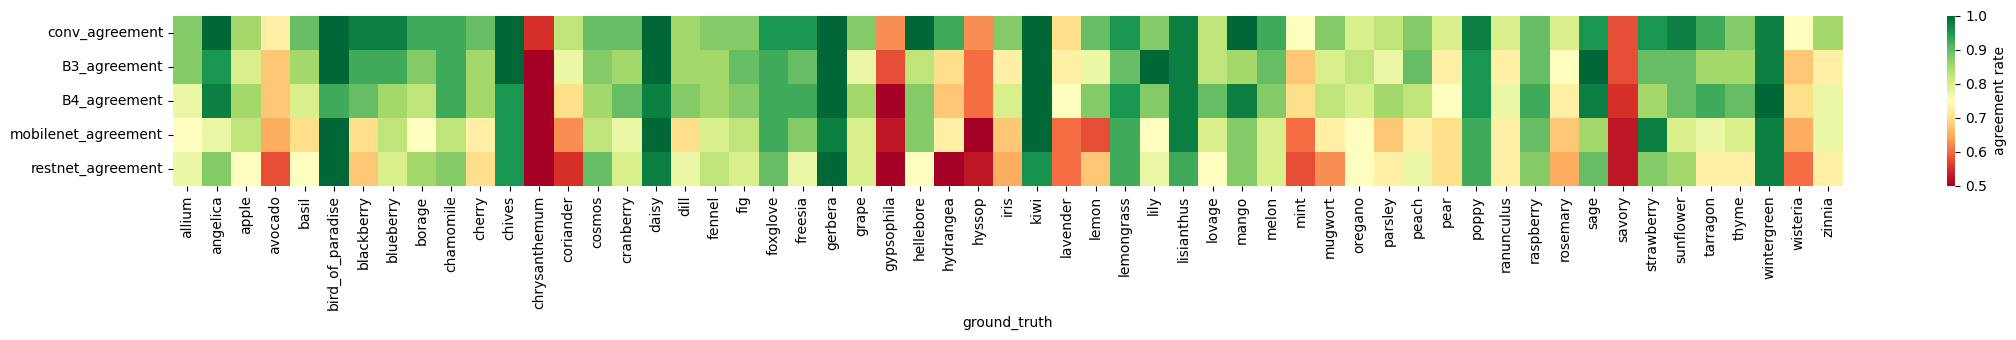

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

agreement_rates = predictions.groupby("ground_truth")[agreement_cols].mean().T
# rows = agreement columns, cols = ground_truth classes, values in [0, 1]

plt.figure(figsize=(max(8, 0.4 * agreement_rates.shape[1]), 0.5 * len(agreement_cols) + 1))
sns.heatmap(agreement_rates, annot=False, fmt=".2f", cmap="RdYlGn",
            vmin=0.5, vmax=1, cbar_kws={"label": "agreement rate"})
plt.xticks(rotation=90)
plt.tight_layout()